<a href="https://colab.research.google.com/github/Faisal0112/TNS/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving weight-height.csv to weight-height.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('weight-height.csv')

# Display first 5 rows
print(df.head())

  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801


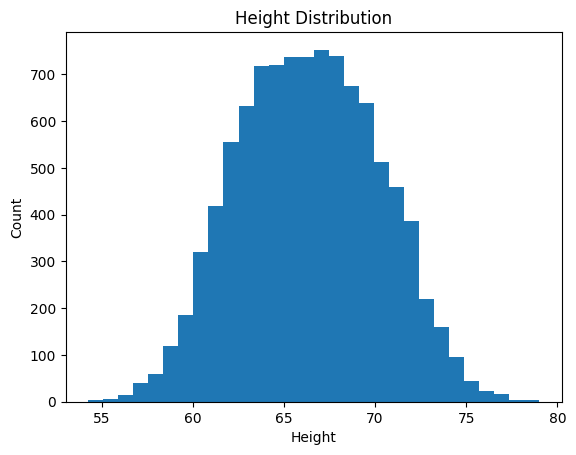

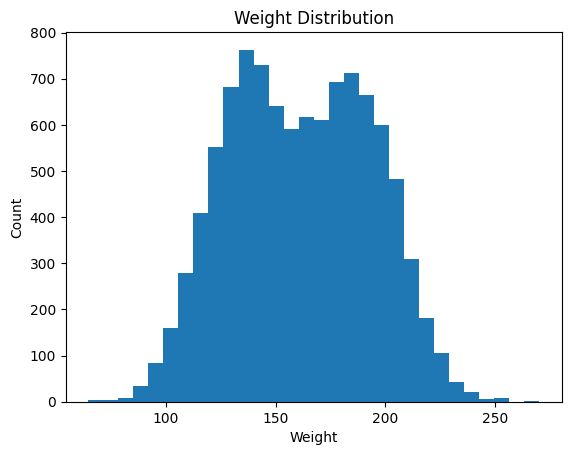

In [5]:
# Histogram for Height
plt.hist(df['Height'], bins=30)
plt.xlabel('Height')
plt.ylabel('Count')
plt.title('Height Distribution')
plt.show()

# Histogram for Weight
plt.hist(df['Weight'], bins=30)
plt.xlabel('Weight')
plt.ylabel('Count')
plt.title('Weight Distribution')
plt.show()

In [6]:
# Calculate Q1 and Q3
Q1_weight = df['Weight'].quantile(0.25)
Q3_weight = df['Weight'].quantile(0.75)

# Calculate IQR
IQR_weight = Q3_weight - Q1_weight

# Find limits
lower_weight = Q1_weight - 1.5 * IQR_weight
upper_weight = Q3_weight + 1.5 * IQR_weight

# Detect outliers
weight_outliers = df[(df['Weight'] < lower_weight) | (df['Weight'] > upper_weight)]

print("Weight Outliers:")
print(weight_outliers)

Weight Outliers:
     Gender     Height      Weight
2014   Male  78.998742  269.989699


In [8]:
# Mean of Weight
weight_mean = df['Weight'].mean()

# Replace outliers
df_mean = df.copy()

df_mean.loc[
    (df_mean['Weight'] < lower_weight) |
    (df_mean['Weight'] > upper_weight),
    'Weight'
] = weight_mean

In [13]:
# Mean of Height
height_mean = df['Height'].mean()

# Calculate Q1 and Q3 for Height
Q1_height = df['Height'].quantile(0.25)
Q3_height = df['Height'].quantile(0.75)

# Calculate IQR for Height
IQR_height = Q3_height - Q1_height

# Find limits for Height outliers
lower_height = Q1_height - 1.5 * IQR_height
upper_height = Q3_height + 1.5 * IQR_height

# Replace outliers
df_mean.loc[
    (df_mean['Height'] < lower_height) |
    (df_mean['Height'] > upper_height),
    'Height'
] = height_mean

print("Dataset after replacing outliers with MEAN:")
print(df_mean)

Dataset after replacing outliers with MEAN:
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [14]:
# Median values
weight_median = df['Weight'].median()
height_median = df['Height'].median()

# Copy dataset
df_median = df.copy()

# Replace weight outliers
df_median.loc[
    (df_median['Weight'] < lower_weight) |
    (df_median['Weight'] > upper_weight),
    'Weight'
] = weight_median

# Replace height outliers
df_median.loc[
    (df_median['Height'] < lower_height) |
    (df_median['Height'] > upper_height),
    'Height'
] = height_median

print("Dataset after replacing outliers with MEDIAN:")
print(df_median)

Dataset after replacing outliers with MEDIAN:
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]
